# 📊 Análisis Exploratorio de Churn

**Proyecto:** Predicción de Churn — Telco Customer Dataset (IBM)
**Analista:** Iván Medrano

---

## Objetivo
Analizar patrones de churn en la base de clientes y preparar los datos para el modelo predictivo (`train_model.py`).

## 1️⃣ Importar librerías

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías importadas correctamente")
print(f"📅 Fecha de análisis: {datetime.now().strftime('%d/%m/%Y %H:%M')}")

✅ Librerías importadas correctamente
📅 Fecha de análisis: 25/07/2026 04:03


## 2️⃣ Cargar datos

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

print("📥 Cargando datos...")
df = pd.read_csv(url)

print(f"✅ Datos cargados exitosamente")
print(f"📊 Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")

📥 Cargando datos...


✅ Datos cargados exitosamente
📊 Dimensiones: 7,043 filas x 21 columnas


Primeras 5 filas del dataset:

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3️⃣ Exploración inicial

In [4]:
print("="*70)
print("📋 INFORMACIÓN GENERAL DEL DATASET")
print("="*70)

print(f"\nTipos de datos:")
print(df.dtypes.value_counts())

print(f"\n\n❓ Valores nulos por columna:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✅ No hay valores nulos")

📋 INFORMACIÓN GENERAL DEL DATASET

Tipos de datos:
str        18
int64       2
float64     1
Name: count, dtype: int64


❓ Valores nulos por columna:
✅ No hay valores nulos


Estadísticas descriptivas de las variables numéricas:

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4️⃣ Análisis de churn

In [6]:
print("="*70)
print("🎯 ANÁLISIS DE CHURN")
print("="*70)

total_customers = len(df)
churned_customers = (df['Churn'] == 'Yes').sum()
active_customers = (df['Churn'] == 'No').sum()
churn_rate = churned_customers / total_customers

print(f"\n📊 MÉTRICAS CLAVE:")
print(f"   • Total de clientes: {total_customers:,}")
print(f"   • Clientes activos: {active_customers:,} ({active_customers/total_customers:.1%})")
print(f"   • Clientes perdidos: {churned_customers:,} ({churn_rate:.1%})")
print(f"   • 📈 Tasa de Churn: {churn_rate:.1%}")

🎯 ANÁLISIS DE CHURN

📊 MÉTRICAS CLAVE:
   • Total de clientes: 7,043
   • Clientes activos: 5,174 (73.5%)
   • Clientes perdidos: 1,869 (26.5%)
   • 📈 Tasa de Churn: 26.5%


## 5️⃣ Visualizaciones principales

In [7]:
current_dir = Path.cwd()
project_root = current_dir.parent
plots_dir = project_root / "outputs" / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
save_path = plots_dir / "analisis_exploratorio.png"


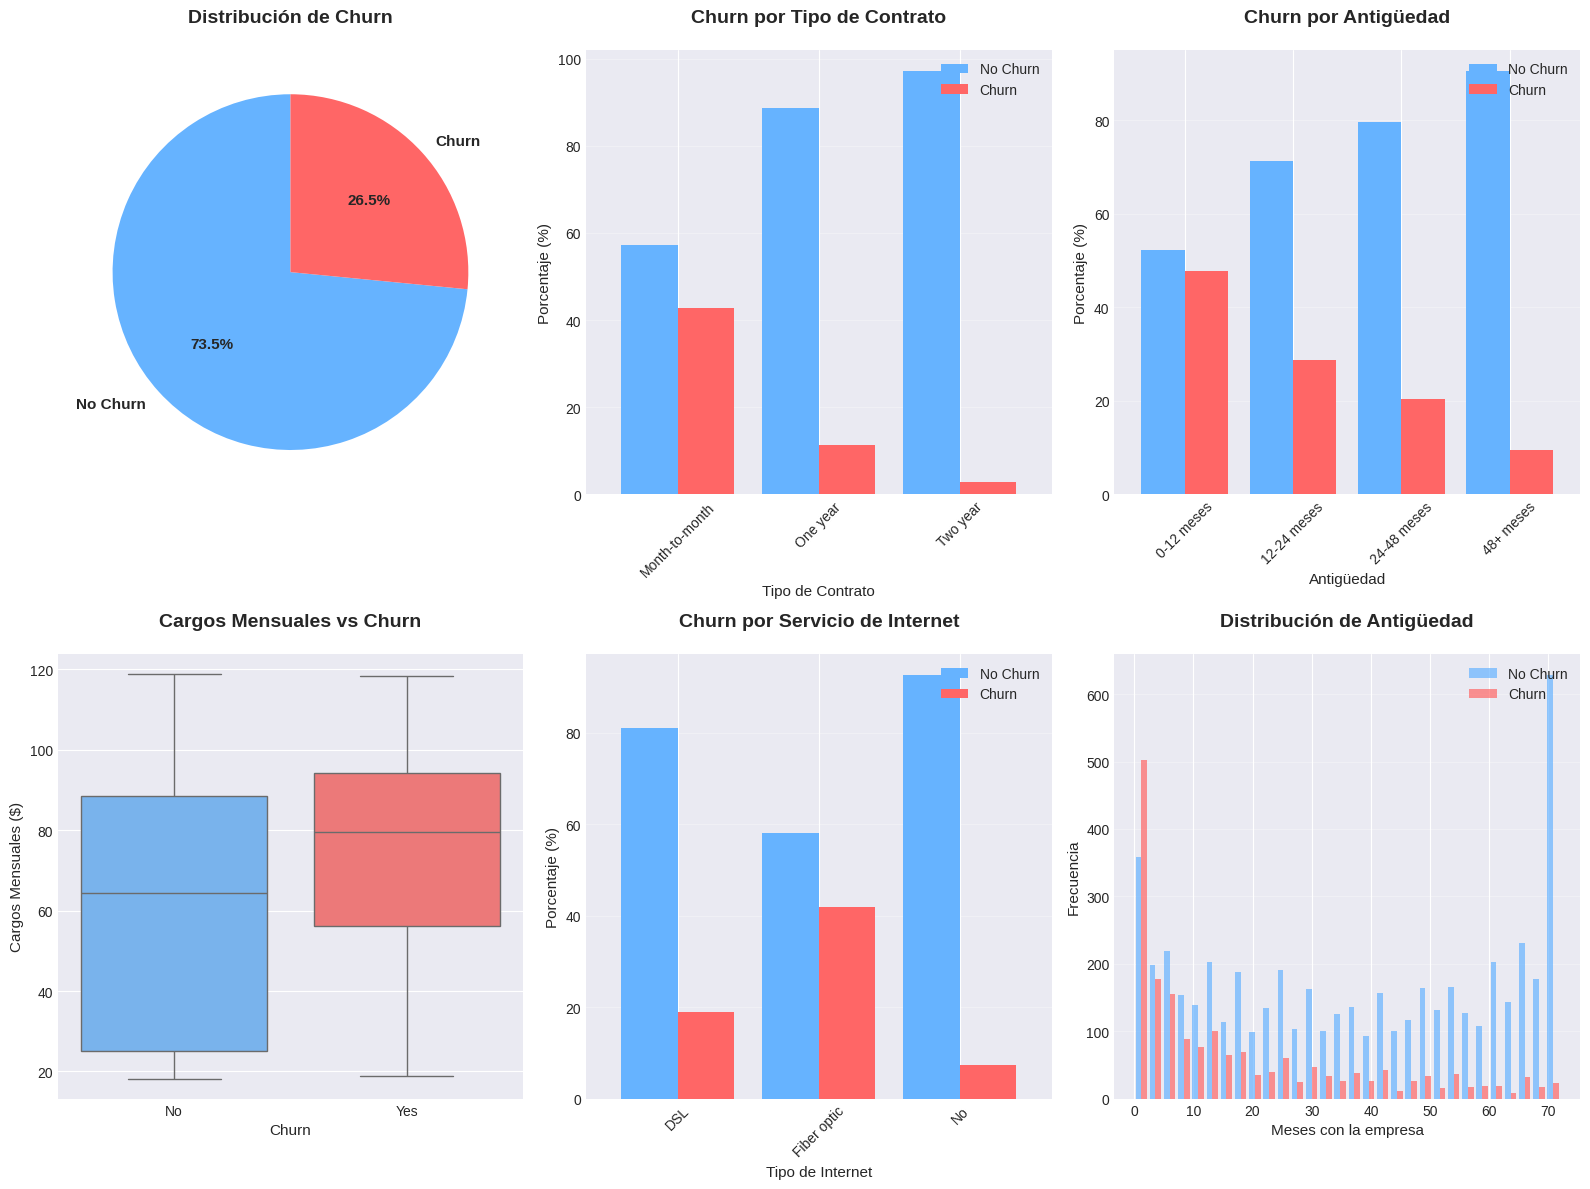


✅ Gráficos guardados exitosamente en:
📂 /home/claude/churn/outputs/plots/analisis_exploratorio.png


In [8]:
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(2, 3, 1)
churn_counts = df['Churn'].value_counts()
colors = ['#66b3ff', '#ff6666']
ax1.pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
ax1.set_title('Distribución de Churn', fontsize=14, fontweight='bold', pad=20)

ax2 = plt.subplot(2, 3, 2)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', ax=ax2, color=colors, width=0.8)
ax2.set_title('Churn por Tipo de Contrato', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Tipo de Contrato', fontsize=11)
ax2.set_ylabel('Porcentaje (%)', fontsize=11)
ax2.legend(['No Churn', 'Churn'], loc='upper right')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

ax3 = plt.subplot(2, 3, 3)
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 100],
                             labels=['0-12 meses', '12-24 meses', '24-48 meses', '48+ meses'])
tenure_churn = pd.crosstab(df['tenure_group'], df['Churn'], normalize='index') * 100
tenure_churn.plot(kind='bar', ax=ax3, color=colors, width=0.8)
ax3.set_title('Churn por Antigüedad', fontsize=14, fontweight='bold', pad=20)
ax3.set_xlabel('Antigüedad', fontsize=11)
ax3.set_ylabel('Porcentaje (%)', fontsize=11)
ax3.legend(['No Churn', 'Churn'], loc='upper right')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

ax4 = plt.subplot(2, 3, 4)
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
# FIX: df.boxplot() dibuja cajas sin relleno (patch_artist=False), casi
# invisibles contra el fondo gris del estilo seaborn-darkgrid. Se usa
# sns.boxplot con la misma paleta de colores que el resto de la figura,
# para que sea visualmente consistente y legible.
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax4,
            hue='Churn', palette={'No': '#66b3ff', 'Yes': '#ff6666'}, legend=False)
ax4.set_title('Cargos Mensuales vs Churn', fontsize=14, fontweight='bold', pad=20)
ax4.set_xlabel('Churn', fontsize=11)
ax4.set_ylabel('Cargos Mensuales ($)', fontsize=11)

ax5 = plt.subplot(2, 3, 5)
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', ax=ax5, color=colors, width=0.8)
ax5.set_title('Churn por Servicio de Internet', fontsize=14, fontweight='bold', pad=20)
ax5.set_xlabel('Tipo de Internet', fontsize=11)
ax5.set_ylabel('Porcentaje (%)', fontsize=11)
ax5.legend(['No Churn', 'Churn'], loc='upper right')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(axis='y', alpha=0.3)

ax6 = plt.subplot(2, 3, 6)
ax6.hist([df[df['Churn']=='No']['tenure'], df[df['Churn']=='Yes']['tenure']],
         bins=30, label=['No Churn', 'Churn'], color=colors, alpha=0.7)
ax6.set_title('Distribución de Antigüedad', fontsize=14, fontweight='bold', pad=20)
ax6.set_xlabel('Meses con la empresa', fontsize=11)
ax6.set_ylabel('Frecuencia', fontsize=11)
ax6.legend(loc='upper right')
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráficos guardados exitosamente en:")
print(f"📂 {save_path}")

## 6️⃣ Insights clave

In [9]:
print("="*70)
print("💡 INSIGHTS PRINCIPALES")
print("="*70)

print("\n1️⃣ IMPACTO DEL TIPO DE CONTRATO:")
contract_analysis = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
for contract, rate in contract_analysis.items():
    emoji = "🔴" if rate > 40 else "🟡" if rate > 20 else "🟢"
    print(f"   {emoji} {contract}: {rate:.1f}% de churn")

print("\n2️⃣ IMPACTO DE LA ANTIGÜEDAD:")
tenure_analysis = df.groupby('tenure_group')['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
for tenure, rate in tenure_analysis.items():
    emoji = "🔴" if rate > 40 else "🟡" if rate > 20 else "🟢"
    print(f"   {emoji} {tenure}: {rate:.1f}% de churn")

print("\n3️⃣ IMPACTO DE CARGOS MENSUALES:")
avg_charges_churn = df[df['Churn']=='Yes']['MonthlyCharges'].mean()
avg_charges_no_churn = df[df['Churn']=='No']['MonthlyCharges'].mean()
print(f"   • Promedio clientes que se fueron: ${avg_charges_churn:.2f}")
print(f"   • Promedio clientes activos: ${avg_charges_no_churn:.2f}")
print(f"   • Diferencia: ${avg_charges_churn - avg_charges_no_churn:.2f} más alto")

print("\n4️⃣ IMPACTO DEL SERVICIO DE INTERNET:")
internet_analysis = df.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
for service, rate in internet_analysis.items():
    emoji = "🔴" if rate > 40 else "🟡" if rate > 20 else "🟢"
    print(f"   {emoji} {service}: {rate:.1f}% de churn")

💡 INSIGHTS PRINCIPALES

1️⃣ IMPACTO DEL TIPO DE CONTRATO:
   🔴 Month-to-month: 42.7% de churn
   🟢 One year: 11.3% de churn
   🟢 Two year: 2.8% de churn

2️⃣ IMPACTO DE LA ANTIGÜEDAD:
   🔴 0-12 meses: 47.7% de churn
   🟡 12-24 meses: 28.7% de churn
   🟡 24-48 meses: 20.4% de churn
   🟢 48+ meses: 9.5% de churn

3️⃣ IMPACTO DE CARGOS MENSUALES:
   • Promedio clientes que se fueron: $74.44
   • Promedio clientes activos: $61.27
   • Diferencia: $13.18 más alto

4️⃣ IMPACTO DEL SERVICIO DE INTERNET:
   🟢 DSL: 19.0% de churn
   🔴 Fiber optic: 41.9% de churn
   🟢 No: 7.4% de churn


## 7️⃣ Recomendaciones estratégicas

In [10]:
print("="*70)
print("🎯 RECOMENDACIONES BASADAS EN DATOS")
print("="*70)

print("""
PRIORIDAD ALTA (implementar en próximos 30 días):

1. 📋 ENFOCARSE EN CONTRATOS DE LARGO PLAZO
   • Los contratos mes a mes tienen ~3-4x más churn que los anuales/bianuales
   • Acción: ofrecer descuentos atractivos para migrar a contratos anuales
   • Meta: convertir 30% de clientes mes-a-mes a plan anual

2. 🆕 PROGRAMA DE RETENCIÓN PARA CLIENTES NUEVOS
   • Los primeros 12 meses concentran la mayor tasa de churn (47.7%)
   • Acción: check-in proactivo al mes 1, 3 y 6
   • Meta: reducir churn en clientes nuevos en 25%

3. 💰 OPTIMIZAR ESTRUCTURA DE PRECIOS
   • Clientes con cargos mensuales más altos muestran mayor riesgo
   • Acción: revisar relación precio-valor, especialmente en fibra óptica
   • Meta: paquetes más competitivos para el segmento de alto cargo

PRIORIDAD MEDIA (60-90 días):

4. 🌐 MEJORAR EXPERIENCIA DE FIBRA ÓPTICA
   • Mayor churn se concentra en clientes con fibra (41.9%)
   • Acción: auditoría de calidad de servicio y soporte técnico
   • Meta: igualar retención con otros tipos de servicio de internet

5. 📊 MODELO PREDICTIVO DE CHURN (este proyecto)
   • Identificar clientes en riesgo antes de que se vayan
   • Ver train_model.py para el modelo y su umbral de decisión optimizado
""")

🎯 RECOMENDACIONES BASADAS EN DATOS

PRIORIDAD ALTA (implementar en próximos 30 días):

1. 📋 ENFOCARSE EN CONTRATOS DE LARGO PLAZO
   • Los contratos mes a mes tienen ~3-4x más churn que los anuales/bianuales
   • Acción: ofrecer descuentos atractivos para migrar a contratos anuales
   • Meta: convertir 30% de clientes mes-a-mes a plan anual

2. 🆕 PROGRAMA DE RETENCIÓN PARA CLIENTES NUEVOS
   • Los primeros 12 meses concentran la mayor tasa de churn (47.7%)
   • Acción: check-in proactivo al mes 1, 3 y 6
   • Meta: reducir churn en clientes nuevos en 25%

3. 💰 OPTIMIZAR ESTRUCTURA DE PRECIOS
   • Clientes con cargos mensuales más altos muestran mayor riesgo
   • Acción: revisar relación precio-valor, especialmente en fibra óptica
   • Meta: paquetes más competitivos para el segmento de alto cargo

PRIORIDAD MEDIA (60-90 días):

4. 🌐 MEJORAR EXPERIENCIA DE FIBRA ÓPTICA
   • Mayor churn se concentra en clientes con fibra (41.9%)
   • Acción: auditoría de calidad de servicio y soporte técn

## 8️⃣ Preparación de datos para el modelo

In [11]:
print("="*70)
print("🔧 PREPARACIÓN DE DATOS PARA MODELO ML")
print("="*70)

print("\n1. Limpiando datos...")
df_model = df.copy()

df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')
df_model['TotalCharges'] = df_model['TotalCharges'].fillna(df_model['TotalCharges'].median())
print("   ✅ TotalCharges convertido y valores nulos imputados")

df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})
print("   ✅ Variable target convertida a binaria")

df_model = df_model.drop('customerID', axis=1, errors='ignore')
print("   ✅ customerID eliminado")

print("\n2. Aplicando one-hot encoding...")
cat_cols = df_model.select_dtypes(include='object').columns
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
print(f"   ✅ {len(cat_cols)} variables categóricas codificadas")

print(f"\n3. Dataset final para modelo:")
print(f"   • Filas: {df_model.shape[0]:,}")
print(f"   • Features: {df_model.shape[1] - 1}")
print(f"   • Target: Churn (0/1)")
print("\n✅ Datos listos para entrenamiento de modelo")

# NOTA: el pipeline real de entrenamiento vive en src/train_model.py y
# src/preprocessing.py (con stratify, class_weight, holdout real y umbral
# óptimo). Este bloque es solo para validar visualmente el preprocesamiento
# durante la exploración, no se usa para entrenar el modelo final.

🔧 PREPARACIÓN DE DATOS PARA MODELO ML

1. Limpiando datos...
   ✅ TotalCharges convertido y valores nulos imputados
   ✅ Variable target convertida a binaria
   ✅ customerID eliminado

2. Aplicando one-hot encoding...
   ✅ 15 variables categóricas codificadas

3. Dataset final para modelo:
   • Filas: 7,043
   • Features: 31
   • Target: Churn (0/1)

✅ Datos listos para entrenamiento de modelo


Primeras filas del dataset ya codificado (`df_model`), listo para el pipeline de entrenamiento:

In [12]:
df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,tenure_group,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0-12 meses,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,24-48 meses,True,False,False,True,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,0-12 meses,True,False,False,True,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,24-48 meses,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,0-12 meses,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False


## 9️⃣ Resumen ejecutivo

In [13]:
# FIX: los $1,500 y $50 originales eran constantes inventadas sin respaldo
# en los datos. Aquí se estima el ingreso anual perdido usando el promedio
# REAL de MonthlyCharges de los clientes que hicieron churn (dato del propio
# dataset), anualizado. Sigue siendo una estimación (asume 12 meses de vida
# restante promedio), pero es una estimación *trazable*, no un número mágico.
avg_monthly_charge_churned = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
annual_value_per_customer = avg_monthly_charge_churned * 12

print("="*70)
print("📊 RESUMEN EJECUTIVO")
print("="*70)

print(f"""
DATOS ANALIZADOS:
- Total de clientes: {total_customers:,}
- Variables analizadas: {df.shape[1]}

SITUACIÓN ACTUAL:
- Tasa de Churn: {churn_rate:.1%}
- Clientes perdidos: {churned_customers:,}
- Cargo mensual promedio de clientes perdidos: ${avg_monthly_charge_churned:.2f}
- Impacto estimado (anualizado, supuesto 12 meses de vida restante):
  ${churned_customers * annual_value_per_customer:,.0f} en revenue perdido

FACTORES CLAVE DE CHURN:
1. Tipo de contrato (mes a mes = mayor riesgo)
2. Antigüedad (primeros 12 meses críticos)
3. Cargos mensuales (más alto = más riesgo)
4. Servicio de internet (fibra = más churn)

PRÓXIMOS PASOS:
✅ Entrenar modelo predictivo (ver src/train_model.py)
✅ Identificar clientes en riesgo (ver src/predict.py)
✅ Implementar estrategias de retención por segmento
✅ Monitorear resultados mensualmente

NOTA METODOLÓGICA:
El supuesto de 12 meses de vida restante y el costo de intervención por
cliente son estimaciones de referencia, no cifras de negocio confirmadas.
En un entorno real, estos parámetros deben validarse con el equipo de
finanzas/CRM antes de usarse para decisiones de inversión.
""")

print("\n" + "="*70)
print("✅ ANÁLISIS COMPLETADO")
print("="*70)

📊 RESUMEN EJECUTIVO

DATOS ANALIZADOS:
- Total de clientes: 7,043
- Variables analizadas: 22

SITUACIÓN ACTUAL:
- Tasa de Churn: 26.5%
- Clientes perdidos: 1,869
- Cargo mensual promedio de clientes perdidos: $74.44
- Impacto estimado (anualizado, supuesto 12 meses de vida restante):
  $1,669,570 en revenue perdido

FACTORES CLAVE DE CHURN:
1. Tipo de contrato (mes a mes = mayor riesgo)
2. Antigüedad (primeros 12 meses críticos)
3. Cargos mensuales (más alto = más riesgo)
4. Servicio de internet (fibra = más churn)

PRÓXIMOS PASOS:
✅ Entrenar modelo predictivo (ver src/train_model.py)
✅ Identificar clientes en riesgo (ver src/predict.py)
✅ Implementar estrategias de retención por segmento
✅ Monitorear resultados mensualmente

NOTA METODOLÓGICA:
El supuesto de 12 meses de vida restante y el costo de intervención por
cliente son estimaciones de referencia, no cifras de negocio confirmadas.
En un entorno real, estos parámetros deben validarse con el equipo de
finanzas/CRM antes de usarse 